In [15]:
import os
import sys
import os.path
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import scipy.sparse as sp
import scipy.stats as st
import math
import gzip
import colorsys
import pickle as pk
import pandas as pd
import urllib.request
from collections import defaultdict, Counter, ChainMap
np.long = int  # Patch missing alias
import scipy.stats as st
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as dist
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import fcluster
import matplotlib.pyplot as plt
import csv
from itertools import islice
import pickle
import json
import obonet

In [2]:
def download_mapping_file(url, filename):
    urllib.request.urlretrieve(url, filename)

def parse_mapping_file(filename):
    mapping = {}
    with gzip.open(filename, 'rt') as file:
        for line in file:
            if line.startswith('#'):  # Skip header and comments
                continue
            fields = line.strip().split('\t')
            if fields[0] == '9606':
                gene_symbol = fields[2]
                entrez_id = fields[1]
                ensembl_id = fields[5]
                # Additional mapping field
                gene_name = fields[11]
                if gene_symbol not in mapping:
                    mapping[gene_symbol] = {
                        'entrez_id': entrez_id,
                        'ensembl_id': ensembl_id,
                        'gene_name': gene_name
                    }
    return mapping


def convert_symbols_to_entrez(gene_symbols, mapping):
    entrez_ids = []
    for symbol in gene_symbols:
        if symbol in mapping:
            entrez_ids.append(mapping[symbol]['entrez_id'])
    return entrez_ids

def convert_symbols_to_ensembl(gene_symbols, mapping):
    ensembl_ids = []
    for symbol in gene_symbols:
        if symbol in mapping:
            ensembl_ids.append(mapping[symbol]['ensembl_id'])
    return ensembl_ids

# # Download Gene Info file (example using Homo sapiens)
url = 'ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz'
filename = 'Homo_sapiens.gene_info.gz'
download_mapping_file(url, filename)

# Parse mapping file
mapping = parse_mapping_file(filename)

# Generate a dictionary of all existing gene symbols and their corresponding Entrez IDs and Ensemble IDs
all_gene_symbols = list(mapping.keys())
all_entrez_ids = [mapping[symbol]['entrez_id'] for symbol in all_gene_symbols]
all_ensembl_ids = [mapping[symbol]['ensembl_id'] for symbol in all_gene_symbols]
symbol_to_entrez = dict(zip(all_gene_symbols, all_entrez_ids))
symbol_to_ensembl = dict(zip(all_gene_symbols, all_ensembl_ids))
entrez_to_symbols = {v: k for k, v in symbol_to_entrez.items()}
ensembl_to_symbols = {v: k for k, v in symbol_to_ensembl.items()}

In [3]:
# READ PPI GRAPH

# PPI physical
path = 'data/'
G_ppi = nx.read_edgelist(path + 'PPI_physical_elist.csv',data=False, delimiter=',')

lcc = max(nx.connected_components(G_ppi), key=len)
G = nx.subgraph(G_ppi,lcc)

In [5]:
# READ DISEASE MODULES

# Replace with correct path
with open('d_doup_genes.pkl', 'rb') as file:
    disease_genes = pickle.load(file)

print(disease_genes)

{'DOID:11054': ['389289', '4524', '4353', '27127', '5925', '10735', '26259', '1029', '9649', '1630', '2876', '7015', '2100', '10979', '84966', '2033', '207', '10723', '10', '4893', '1728', '3456', '8085', '84181', '5646', '6648', '2072', '3440', '9582', '3845', '9759', '140767', '26986', '4504', '701', '3479', '538', '3265', '10395', '57412', '7373', '8000', '7037', '1499', '355', '472', '7124', '50807', '3488', '2026', '8313', '5290', '1956', '3908', '3486', '290', '3558', '7442', '4297', '58508', '1890', '225689', '1440', '5423', '330', '11186', '2068', '2186', '3978', '9700', '4016', '6714', '5743', '5690', '3576', '3868', '2261', '4489', '2735', '8314', '10460', '2099', '4502', '4108', '55252', '267', '81037', '2950', '898', '9', '4609', '8836', '2944', '324', '2175', '9611', '6573', '360', '7157', '7874', '2954', '8289', '119391', '3205', '387', '51479', '1387', '513', '999', '7364', '84171', '1026', '1580', '7403', '8320', '5728', '3670', '8243', '5447', '1463', '7799'], 'DOID:39

In [6]:
# KEEP ONLY DISEASES WHERE ALL GENES APPEAR IN OUR PPI

disease_subgraphs = {}

for doid, gene_list in disease_genes.items():
    nodes_in_G = [g for g in gene_list if g in G]
    subgraph = G.subgraph(nodes_in_G).copy()
    disease_subgraphs[doid] = subgraph

In [7]:
# COMPUTE LCC OF EACH DISEASE

disease_subgraphs_lcc = {
    doid: G_sub.subgraph(max(nx.connected_components(G_sub), key=len)).copy()
    for doid, G_sub in disease_subgraphs.items()
    if G_sub.number_of_nodes() > 0
}

In [10]:
# DICTIONARIES THAT CONVERT DOID TO NAME AND NAME TO DOID

with open("doid_to_name.json", "r") as f:
    doid_to_name = json.load(f)
    
    
name_to_doid = {v: k for k, v in doid_to_name.items()}
#print(doid_to_name)

In [11]:
# DICTIONARY WITH KEYS BEING DISEASES NAMES

disease_lcc_by_name = {
    doid_to_name[doid]: graph
    for doid, graph in disease_subgraphs_lcc.items()
    if doid in doid_to_name
}

In [12]:
# FILTER OUT ONLY CANCER RELATED DISEASES

keywords = [
    "cancer",
    "carcinoma",
    "sarcoma",
    "leukemia",
    "lymphoma",
    "melanoma",
    "malignant"
]

excluded_keywords = [
    "benign",
    "syndrome",
    "pre-malignant",
    "premalignant"
]

cancer_only = {}

for name, graph in disease_lcc_by_name.items():
    lname = name.lower()
    
    if any(bad in lname for bad in excluded_keywords):
        continue
    
    if any(k in lname for k in keywords):
        cancer_only[name] = graph

In [13]:
# KEEP ONLY CANCERS WITH LCC LARGEN THAN 50 NODES

filtered = {
    disease: G
    for disease, G in cancer_only.items()
    if G.number_of_nodes() >= 50
}

In [14]:
# REMOVE THE 5 GENERAL TERMS

to_remove = [
    "cancer",
    "carcinoma",
    "immune system cancer",
    "nervous system cancer",
    "reproductive organ cancer"
]
filtered_filtered = {
    k: v
    for k, v in filtered.items()
    if k not in to_remove
}
print(len(filtered_filtered))

64


In [19]:
# GET DOIDS OF THE SELECTED CANCERS

doids = [name_to_doid[d] for d in filtered_filtered.keys()]
print(len(doids))

64


In [16]:
# LOAD DISEASE ONTOLOGY

url = "https://purl.obolibrary.org/obo/doid.obo"
dis_graph = obonet.read_obo(url)

print(nx.is_directed_acyclic_graph(dis_graph))
print(len(dis_graph.nodes()))

dis_graph = dis_graph.reverse(copy=True)

True
12079


In [17]:
# Compute ancestor of a node
def get_ancestors(term):
    return nx.ancestors(dis_graph, term) | {term}


# Precompute descendants for all nodes
total_nodes = len(dis_graph.nodes())
descendants = {
    node: nx.descendants(dis_graph, node)
    for node in dis_graph.nodes()
}

IC = {}

for node in dis_graph.nodes():
    prob = (len(descendants[node]) + 1) / total_nodes
    IC[node] = -math.log(prob)

    
# Compute lin similairty    
def lin_similarity(t1, t2):
    a1 = get_ancestors(t1)
    a2 = get_ancestors(t2)
    
    common = a1 & a2
    
    if not common:
        return 0.0
    
    # Most Informative Common Ancestor
    mica_ic = max(IC[c] for c in common)
    
    # Avoid division by zero
    if IC[t1] + IC[t2] == 0:
        return 0.0
    
    return (2 * mica_ic) / (IC[t1] + IC[t2])

In [20]:
# COMPUTE LIN SIMILARITY MATRIX

n = len(doids)
S_l = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        score = lin_similarity(doids[i], doids[j])
        S_l[i, j] = score
        S_l[j, i] = score
        
print(S_l)

[[1.         0.9040527  0.48512434 ... 0.66255331 0.61392949 0.30928457]
 [0.9040527  1.         0.55930069 ... 0.71266577 0.65671897 0.3378506 ]
 [0.48512434 0.55930069 1.         ... 0.35379421 0.31903811 0.46041763]
 ...
 [0.66255331 0.71266577 0.35379421 ... 1.         0.72356509 0.25009735]
 [0.61392949 0.65671897 0.31903811 ... 0.72356509 1.         0.23221452]
 [0.30928457 0.3378506  0.46041763 ... 0.25009735 0.23221452 1.        ]]


In [ ]:
# SAVE SIMILARITY MATRIX FOR LATER USE

# np.savez_compressed(
#     "lin_similarity_with_labels.npz",
#     S_l=S_l,
#     doids=doids
# )

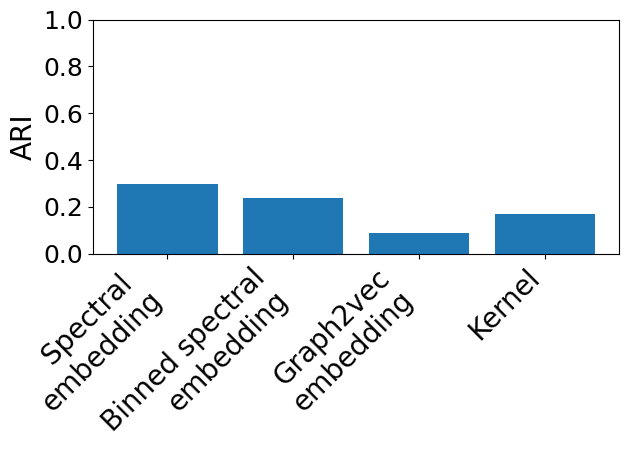

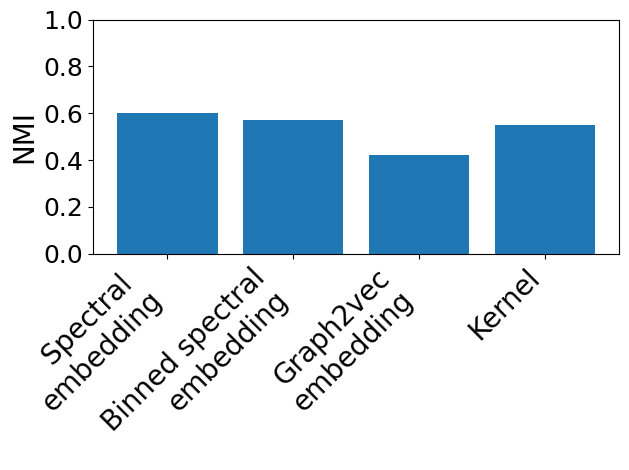

In [21]:
# PLOT RESULTS OF CLUSTERINGS FROM CLUSTERING_DISEASES FILE

labels = [
    "Spectral \nembedding",
    "Binned spectral\nembedding",
    "Graph2vec\nembedding",
    "Kernel"
]
values_ari = [0.3, 0.24, 0.09, 0.17]
values_nmi = [0.6, 0.57, 0.42, 0.55]

plt.figure()
plt.bar(labels, values_ari)
plt.ylim(0, 1)
plt.yticks(fontsize = 18)
plt.ylabel("ARI", fontsize = 20)
plt.xticks(fontsize=20, rotation=45, ha='right')
#plt.savefig("ari_diseases.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()


plt.figure()
plt.bar(labels, values_nmi)
plt.ylim(0, 1)
plt.yticks(fontsize = 18)
plt.ylabel("NMI", fontsize = 20)
plt.xticks(fontsize=20, rotation=45, ha='right')
#plt.savefig("nmi_diseases.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()